In [21]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
import pandas as pd

In [22]:
def plotting_routine(data_bgk, data_trixi, M):
    fig, axs = plt.subplots()
    plt.title('BGK vs. Extended Gramian Closure, M={}'.format(M))

    # Density
    axs.plot(data_trixi['x'], data_trixi['rho'], color='blue', linestyle='solid')
    axs.plot(data_bgk['x'], data_bgk['rho'], color='blue', linestyle='dashed')

    # Pressure
    axs.plot(data_trixi['x'], data_trixi['p'], color='green', linestyle='solid')
    axs.plot(data_bgk['x'], data_bgk['p'], color='green', linestyle='dashed')

    axs.set_ylabel('$\\rho$, $p$')

    # Velocity
    axtwin = axs.twinx()
    axtwin.plot(data_trixi['x'], data_trixi['v'], color='red', linestyle='solid')
    axtwin.plot(data_bgk['x'], data_bgk['v'], color='red', linestyle='dashed')
    axtwin.set_ylabel('$v$')

    # Legend
    axs.plot([], [], 'b-', label='$\\rho$')
    axs.plot([], [], 'r-', label='$v$')
    axs.plot([], [], 'g-', label='$p$')
    axs.plot([], [], 'k-', label='Ext Gram')
    axs.plot([], [], 'k--', label='BGK')
    axs.legend(loc='upper right')

    axs.grid(True)

    axs.set_xlim(-2., 2.)
    axs.set_xlabel('x')
    return fig, axs

In [23]:
def plotting_routine_all(data_bgk, data_gramian, M_vector):
    fig, axs = plt.subplots()

    # Density
    axs.plot(data_gramian[0]['x'], data_gramian[0]['rho'], color='blue', linestyle='dashed')
    axs.plot(data_gramian[-1]['x'], data_gramian[-1]['rho'], color='blue', linestyle='dotted')
    axs.plot(data_bgk['x'], data_bgk['rho'], color='cyan', linestyle='solid')

    # Pressure
    axs.plot(data_gramian[0]['x'], data_gramian[0]['p'], color='green', linestyle='dashed')
    axs.plot(data_gramian[-1]['x'], data_gramian[-1]['p'], color='green', linestyle='dotted')
    axs.plot(data_bgk['x'], data_bgk['p'], color='lime', linestyle='solid')

    axs.set_ylabel('$\\rho$, $p$')

    # Velocity
    axtwin = axs.twinx()
    axtwin.plot(data_gramian[0]['x'], data_gramian[0]['v'], color='red', linestyle='dashed')
    axtwin.plot(data_gramian[-1]['x'], data_gramian[-1]['v'], color='red', linestyle='dotted')
    axtwin.plot(data_bgk['x'], data_bgk['v'], color='orange', linestyle='solid')
    axtwin.set_ylabel('$v$')

    # Legend
    axs.plot([], [], 'b-', label='$\\rho$')
    axs.plot([], [], 'r-', label='$v$')
    axs.plot([], [], 'g-', label='$p$')
    axs.plot([], [], color='black', linestyle='dashed', label='M={}'.format(M_vector[0]))
    axs.plot([], [], color='black', linestyle='dotted', label='M={}'.format(M_vector[-1]))
    axs.plot([], [], color='black', linestyle='solid', label='BGK')
    axs.legend(loc='upper right')

    axs.grid(True)

    axs.set_xlim(-2., 2.)
    axs.set_xlabel('x')

    return fig, axs

In [24]:
def plotting_convergence(data_bgk, data_gramian, M_vector):
    errors = {}
    for key in ['rho', 'v', 'p']:
        errors[key] = []
        for M in M_vector:
            data_trixi = data_gramian[M_vector.index(M)]
            bgk_interp1d = interp1d(data_bgk['x'], data_bgk[key], kind='linear', fill_value="extrapolate")
            error = np.linalg.norm(bgk_interp1d(data_trixi['x']) - data_trixi[key], 2) / np.linalg.norm(bgk_interp1d(data_trixi['x']), 2)
            errors[key].append(error)
    
    fig, axs = plt.subplots()
    axs.semilogy(M_vector, errors['rho'], marker='o', color='blue')
    twinx = axs.twinx()
    twinx.semilogy(M_vector, errors['v'], marker='o', color='red')
    axs.semilogy(M_vector, errors['p'], marker='o', color='green')
    axs.plot([], [], 'b-', label='$\\rho$')
    axs.plot([], [], 'r-', label='$v$')
    axs.plot([], [], 'g-', label='$p$')
    axs.set_xticks(M_vector)
    axs.set_xlabel('M')
    axs.set_ylabel('$\\epsilon_{rel,2}(\\rho, p)$')
    twinx.set_ylabel('$\\epsilon_{rel,2}(v)$')
    axs.set_title('Convergence Study towards BGK Equation')
    axs.grid(True)
    axs.legend()

    return fig, axs, errors

# Convergence towards BGK

Kn = 1.0

In [25]:
file_bgk = "../out/Riemann1D/bgk_Kn1.0_T_end0.3_rho_L7.0_rho_R1.0_v_L0.0_v_R0.0_theta_L1.0_theta_R1.0_ρ_v_p.csv"
data_bgk = pd.read_csv(file_bgk)

In [26]:
M_vector = [4, 6, 8, 10, 12]
file_gramian = [f"../out/Convergence/ConvergenceEvenOrder/gram_solution_M{M}_Kn1.0_T_end0.3_rho_L7.0_rho_R1.0_v_L0.0_v_R0.0_theta_L1.0_theta_R1.0_ρ_v_p.csv" for M in M_vector]
data_gramian = [pd.read_csv(f) for f in file_gramian]

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_68199/3979240973.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


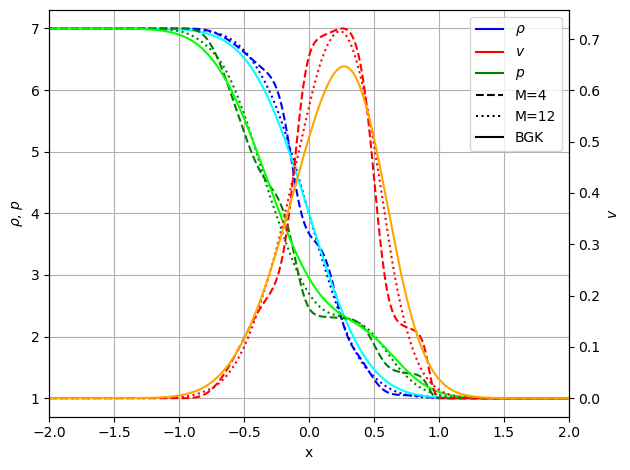

In [27]:

fig, _ = plotting_routine_all(data_bgk, data_gramian, M_vector)
fig.tight_layout()
fig.savefig('../out/Riemann1D/BGK_vs_ExtendedGramian_Kn1.0.pdf')
fig.show()

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_68199/3742684219.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


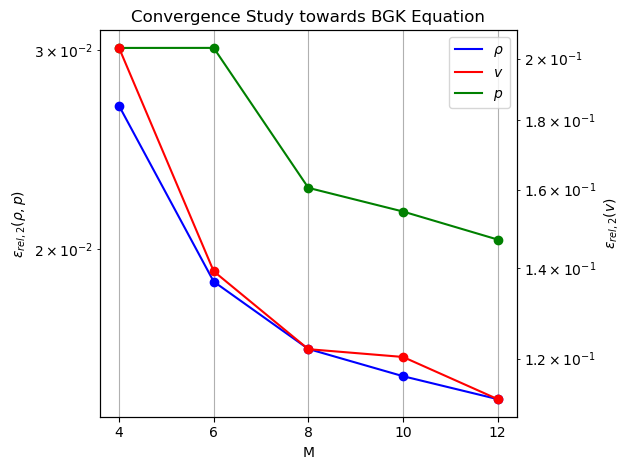

In [28]:
# Convergence study

fig, axs, errors = plotting_convergence(data_bgk, data_gramian, M_vector)

fig.tight_layout()
fig.savefig('../out/Riemann1D/Convergence_BGK_Kn1.0.pdf')
fig.show()

# Analytical solution for f(x,t) for vanishing relaxation term

In [29]:
class Maxwellian:
    def __init__(self, rho, v, theta):
        self.rho = rho
        self.v = v
        self.theta = theta

    def __call__(self, c):
        return self.rho / np.sqrt(2*np.pi*self.theta) * np.exp(-(c-self.v)**2 / (2*self.theta))

def f0(f_left, f_right, x, c):
    x_arr, c_arr = np.broadcast_arrays(np.asarray(x), np.asarray(c))
    return np.where(x_arr < 0, f_left(c_arr), f_right(c_arr))
    
def f(f_left, f_right, x, c, t):
    return f0(f_left, f_right, x - c*t, c)

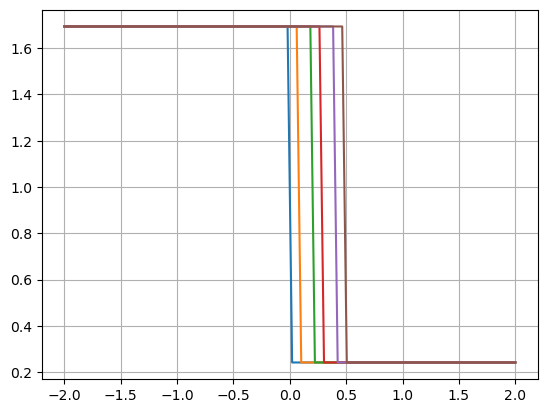

In [30]:
rho_L, v_L, p_L = 7.0, 0.0, 1.0
rho_R, v_R, p_R = 1.0, 0.0, 1.0

maxwellian_L = Maxwellian(rho_L, v_L, p_L)
maxwellian_R = Maxwellian(rho_R, v_R, p_R)

x = np.linspace(-2, 2, 100)
c = np.linspace(-5, 5, 100)
t_array = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
plt.figure()
[plt.plot(x, f(maxwellian_L, maxwellian_R, x, 1.0, t), label='t={:.1f}'.format(t)) for t in t_array]
plt.grid()
plt.show()

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_68199/1060408280.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


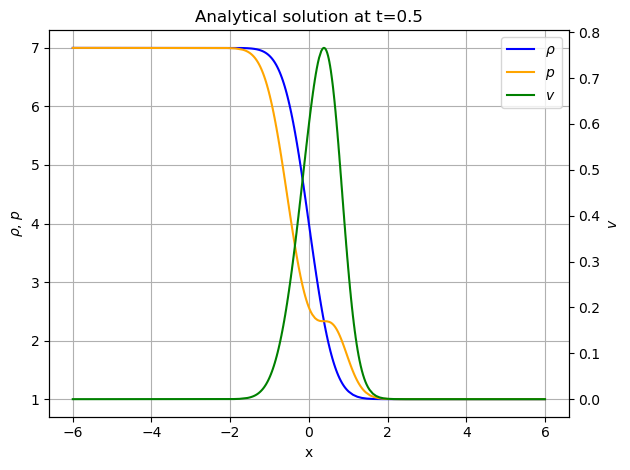

In [31]:
x = np.linspace(-6, 6, 10_000)
c = np.linspace(-10, 10, 10_000)
T = 0.5
f_T = f(maxwellian_L, maxwellian_R, x, c[:, None], T)
rho_T = np.trapz(f_T, c, axis=0)
v_T = np.trapz(c[:, None] * f_T, c, axis=0) / rho_T
theta_T = np.trapz((c[:, None] - v_T)**2 * f_T, c, axis=0) / rho_T
p_T = rho_T * theta_T

fig, axs = plt.subplots()
axs.plot(x, rho_T, label='$\\rho$', color='blue')
axtwin = axs.twinx()
axtwin.plot(x, v_T, label='$v$', color='green')
axs.plot(x, p_T, label='$p$', color='orange')
axs.set_xlabel('x')
axs.set_ylabel('$\\rho$, $p$')
axtwin.set_ylabel('$v$')
legend_lines, legend_labels = axs.get_legend_handles_labels()
legend_lines2, legend_labels2 = axtwin.get_legend_handles_labels()
axs.legend(legend_lines + legend_lines2, legend_labels + legend_labels2, loc='upper right')
axs.set_xlabel('x')
axs.set_title('Analytical solution at t={}'.format(T))
axs.grid()
fig.tight_layout()
fig.savefig('../out/Riemann1D/BGK_analytical_solution_t{}.pdf'.format(T))
fig.show()

In [32]:
# Convergence for analytical solution with zero-source
x = np.linspace(-6, 6, 10_000)
T = 0.3

# Convergence in velocity space
nc = [10, 100, 1_000, 10_000]#!, 100_000]

f_convergence, rho_convergence, v_convergence, theta_convergence, p_convergence = [], [], [], [], []
for c_ in nc:
    c = np.linspace(-10, 10, c_)
    f_convergence.append(f(maxwellian_L, maxwellian_R, x, c[:, None], T))
    rho_convergence.append(np.trapz(f_convergence[-1], c, axis=0))
    v_convergence.append(np.trapz(c[:, None] * f_convergence[-1], c, axis=0) / rho_convergence[-1])
    theta_convergence.append(np.trapz((c[:, None] - v_convergence[-1])**2 * f_convergence[-1], c, axis=0) / rho_convergence[-1])
    p_convergence.append(rho_convergence[-1] * theta_convergence[-1])

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_68199/574598103.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


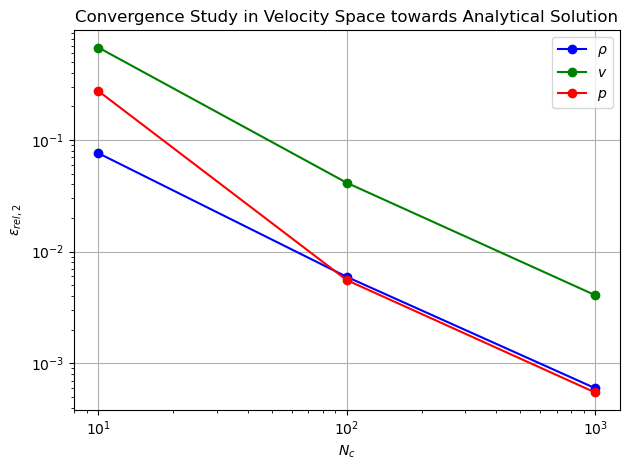

In [33]:
# L2-error
f_error, rho_error, v_error, theta_error, p_error = [], [], [], [], []
for i in range(len(nc) - 1):
    rho_error.append(np.linalg.norm(rho_convergence[-1] - rho_convergence[i], 2) / np.linalg.norm(rho_convergence[-1], 2))
    v_error.append(np.linalg.norm(v_convergence[-1] - v_convergence[i], 2) / np.linalg.norm(v_convergence[-1], 2))
    theta_error.append(np.linalg.norm(theta_convergence[-1] - theta_convergence[i], 2) / np.linalg.norm(theta_convergence[-1], 2))
    p_error.append(np.linalg.norm(p_convergence[-1] - p_convergence[i], 2) / np.linalg.norm(p_convergence[-1], 2))

fig, axs = plt.subplots()
axs.loglog(nc[:-1], rho_error, marker='o', color='blue', label='$\\rho$')
axs.loglog(nc[:-1], v_error, marker='o', color='green', label='$v$')
axs.loglog(nc[:-1], p_error, marker='o', color='red', label='$p$')
axs.set_xlabel('$N_c$')
axs.set_ylabel('$\\epsilon_{rel,2}$')
axs.set_title('Convergence Study in Velocity Space towards Analytical Solution')
axs.grid(True)
axs.legend()
fig.tight_layout()
fig.savefig('../out/Riemann1D/BGK_Analytical_zerosource_Convergence.pdf')
fig.show()

# Convergence of HyQMOM for vanishing relaxation term

In [34]:
x = np.linspace(-6, 6, 10_000)
c = np.linspace(-10, 10, 10_000)
T = 0.3
f_T = f(maxwellian_L, maxwellian_R, x, c[:, None], T)
rho_T = np.trapz(f_T, c, axis=0)
v_T = np.trapz(c[:, None] * f_T, c, axis=0) / rho_T
theta_T = np.trapz((c[:, None] - v_T)**2 * f_T, c, axis=0) / rho_T
p_T = rho_T * theta_T

In [35]:
M_vector = [4, 12]
file_gramian = [f"../out/Convergence/ConvergenceEvenOrder/gram_solution_M{M}_Kn1.0e20_T_end0.3_rho_L7.0_rho_R1.0_v_L0.0_v_R0.0_theta_L1.0_theta_R1.0_ρ_v_p.csv" for M in M_vector]
data_gramian = [pd.read_csv(f) for f in file_gramian]

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_68199/868608042.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


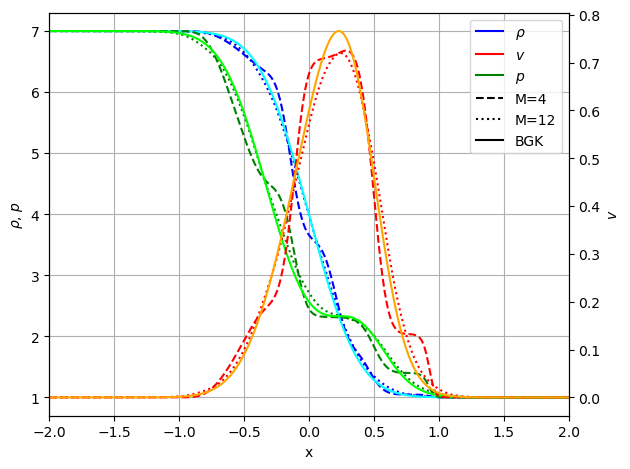

In [36]:
fig, _ = plotting_routine_all(pd.DataFrame({'x': x, 'rho': rho_T, 'v': v_T, 'p': p_T}), data_gramian, M_vector)

fig.tight_layout()
fig.savefig('../out/Riemann1D/BGK_no_relaxation_t{}.pdf'.format(T))
fig.show()

In [37]:
M_vector = [4, 6, 8, 10, 12]
file_gramian = [f"../out/Convergence/ConvergenceEvenOrder/gram_solution_M{M}_Kn1.0e20_T_end0.3_rho_L7.0_rho_R1.0_v_L0.0_v_R0.0_theta_L1.0_theta_R1.0_ρ_v_p.csv" for M in M_vector]
data_gramian = [pd.read_csv(f) for f in file_gramian]

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_68199/227925797.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


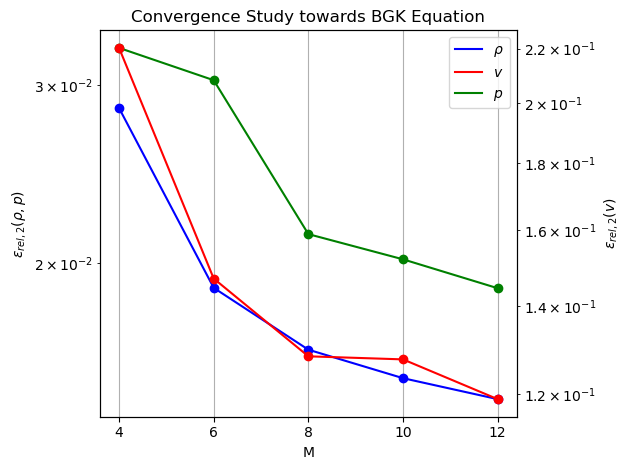

In [38]:
# Convergence study
errors = {}
for key in ['rho', 'v', 'p']:
    errors[key] = []
    for M in M_vector:
        data_trixi = data_gramian[M_vector.index(M)]
        bgk_interp1d = interp1d(data_bgk['x'], data_bgk[key], kind='linear', fill_value="extrapolate")
        error = np.linalg.norm(bgk_interp1d(data_trixi['x']) - data_trixi[key], 2) / np.linalg.norm(bgk_interp1d(data_trixi['x']), 2)
        errors[key].append(error)

fig, axs = plt.subplots()
axs.semilogy(M_vector, errors['rho'], marker='o', color='blue')
twinx = axs.twinx()
twinx.semilogy(M_vector, errors['v'], marker='o', color='red')
axs.semilogy(M_vector, errors['p'], marker='o', color='green')
axs.plot([], [], 'b-', label='$\\rho$')
axs.plot([], [], 'r-', label='$v$')
axs.plot([], [], 'g-', label='$p$')
axs.set_xticks(M_vector)
axs.set_xlabel('M')
axs.set_ylabel('$\\epsilon_{rel,2}(\\rho, p)$')
twinx.set_ylabel('$\\epsilon_{rel,2}(v)$')
axs.set_title('Convergence Study towards BGK Equation')
axs.grid(True)
axs.legend()

fig.tight_layout()
fig.savefig('../out/Riemann1D/Convergence_BGK_no_relaxation.pdf')
fig.show()

# Compare Kn

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_68199/3869429763.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_68199/3869429763.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_68199/3869429763.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_68199/3869429763.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_68199/3869429763.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_68199/3869429763.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be

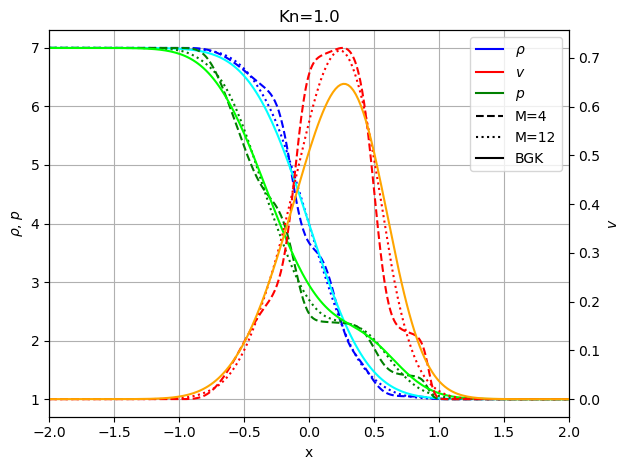

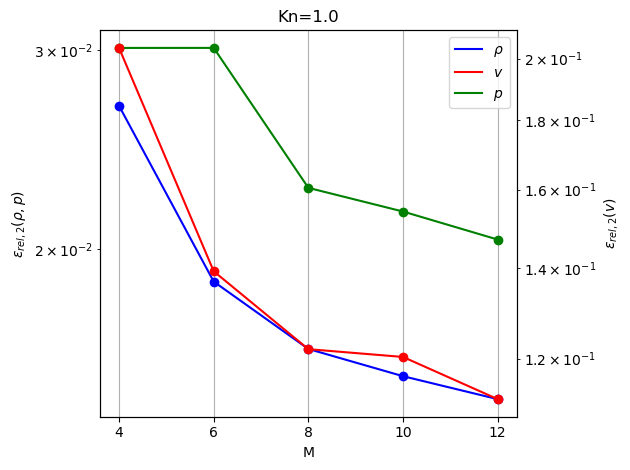

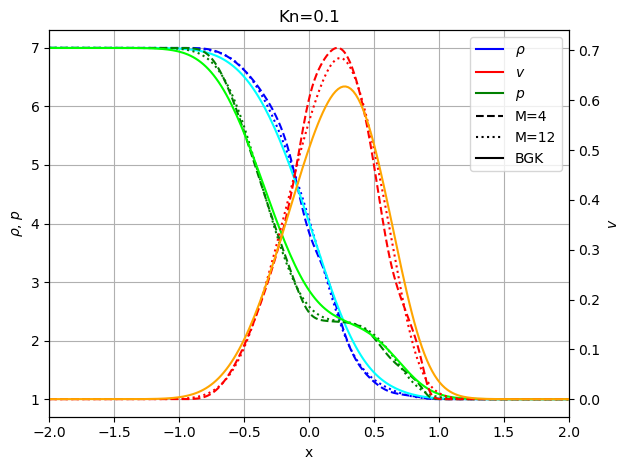

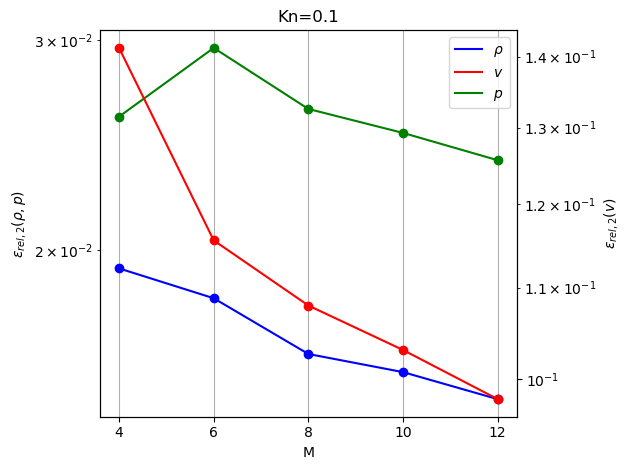

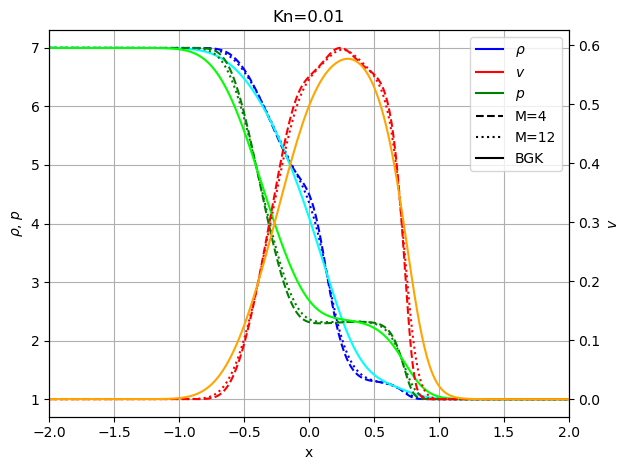

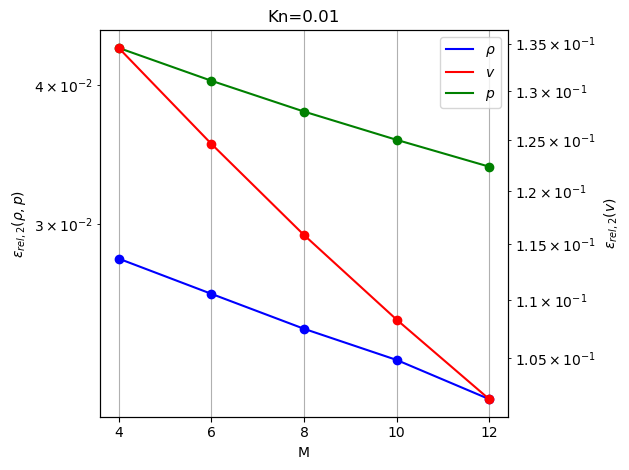

In [39]:
for Kn in [1.0, 0.1, 0.01]:
    file_bgk = f"../out/Riemann1D/bgk_Kn{Kn}_T_end0.3_rho_L7.0_rho_R1.0_v_L0.0_v_R0.0_theta_L1.0_theta_R1.0_ρ_v_p.csv"
    data_bgk = pd.read_csv(file_bgk)

    M_vector = [4, 6, 8, 10, 12]
    file_gramian = [f"../out/Convergence/ConvergenceEvenOrder/gram_solution_M{M}_Kn{Kn}_T_end0.3_rho_L7.0_rho_R1.0_v_L0.0_v_R0.0_theta_L1.0_theta_R1.0_ρ_v_p.csv" for M in M_vector]
    data_gramian = [pd.read_csv(f) for f in file_gramian]

    fig, axs = plotting_routine_all(data_bgk, data_gramian, M_vector)
    axs.set_title('Kn={}'.format(Kn))
    fig.tight_layout()
    fig.savefig('../out/Riemann1D/BGK_vs_ExtendedGramian_Kn{}.pdf'.format(Kn))
    fig.show()

    fig, axs, errors = plotting_convergence(data_bgk, data_gramian, M_vector)
    axs.set_title('Kn={}'.format(Kn))
    fig.tight_layout()
    fig.savefig('../out/Riemann1D/Convergence_BGK_Kn{}.pdf'.format(Kn))
    fig.show()

# What about the Odd Closure?

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_68199/1607761321.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_68199/1607761321.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_68199/1607761321.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_68199/1607761321.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


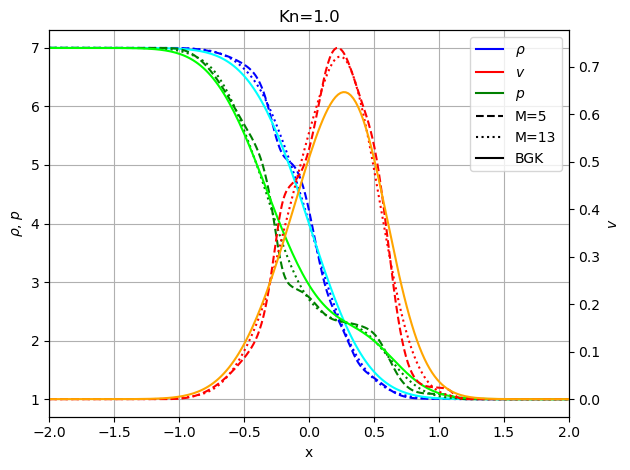

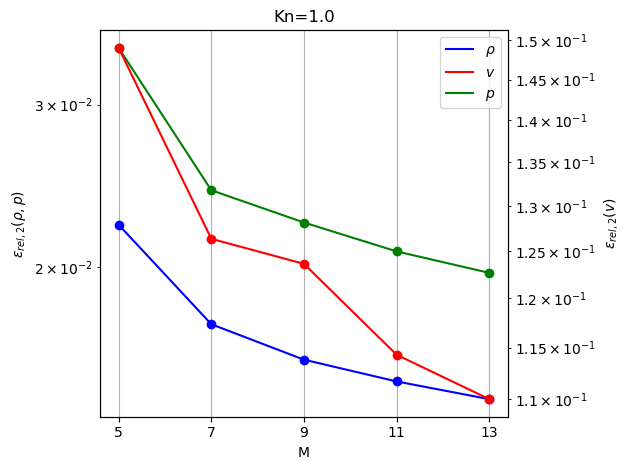

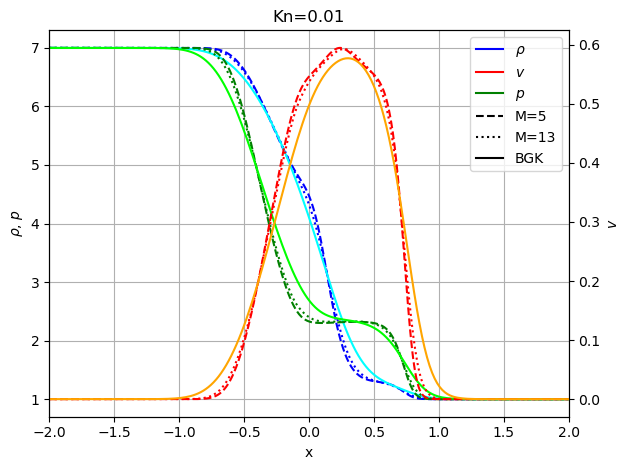

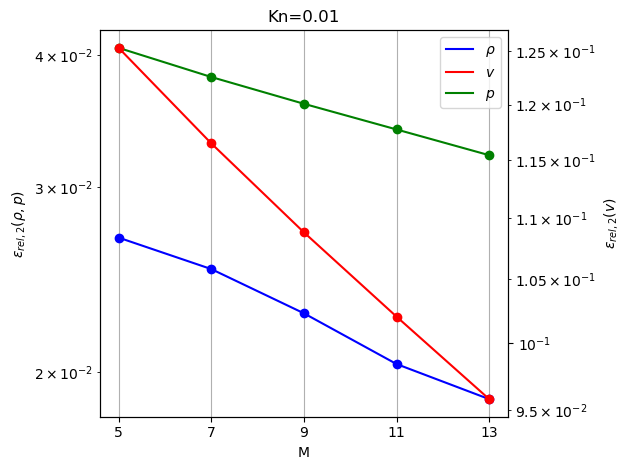

In [40]:
for Kn in [1.0, 0.01]:#[1.0, 0.1, 0.01]:
    file_bgk = f"../out/Riemann1D/bgk_Kn{Kn}_T_end0.3_rho_L7.0_rho_R1.0_v_L0.0_v_R0.0_theta_L1.0_theta_R1.0_ρ_v_p.csv"
    data_bgk = pd.read_csv(file_bgk)

    M_vector = [5, 7, 9, 11, 13]
    file_gramian = [f"../out/Convergence/ConvergenceOddOrder/gram_solution_M{M}_Kn{Kn}_T_end0.3_rho_L7.0_rho_R1.0_v_L0.0_v_R0.0_theta_L1.0_theta_R1.0_ρ_v_p.csv" for M in M_vector]
    data_gramian = [pd.read_csv(f) for f in file_gramian]

    fig, axs = plotting_routine_all(data_bgk, data_gramian, M_vector)
    axs.set_title('Kn={}'.format(Kn))
    fig.tight_layout()
    fig.savefig('../out/Riemann1D/BGK_vs_ExtendedGramian_Odd_Kn{}.pdf'.format(Kn))
    fig.show()

    fig, axs, errors = plotting_convergence(data_bgk, data_gramian, M_vector)
    axs.set_title('Kn={}'.format(Kn))
    fig.tight_layout()
    fig.savefig('../out/Riemann1D/Convergence_BGK_Odd_Kn{}.pdf'.format(Kn))
    fig.show()